# 32 estrellas donde nadie las buscaba

A 13.800 parsecs del Sol, dentro de una nube de gas que cae hacia la Vía Láctea a más de 100 km/s, alguien encontró estrellas recién nacidas. ¿Qué hacen ahí?

---

**Paper:** He et al. (2026) *Star Formation in Circumgalactic High-Velocity Cloud Complex H*
**Journal:** Nature Astronomy
**DOI:** [10.1038/s41550-026-02814-9](https://doi.org/10.1038/s41550-026-02814-9)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-19-estrellas-fuera-via-lactea/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/watch?v=nlptNKxW4Xg)

## El Complejo H: una nube invisible que se estrella contra nuestra galaxia

Alrededor de la Vía Láctea orbitan nubes enormes de gas primitivo — con muy pocos metales — que van cayendo hacia el disco. Se llaman nubes de alta velocidad (HVC, por *high-velocity clouds*). La más grande es el **Complejo H**, y durante décadas nadie encontró estrellas dentro de ella — sin estrellas, no había manera de medir su distancia con precisión.

Usando datos del satélite **Gaia DR3** (que mide posiciones y movimientos de miles de millones de estrellas), un equipo encontró **dos cúmulos abiertos** dentro del Complejo H: **Emei-1** (20 estrellas) y **Emei-2** (12 estrellas). Son jóvenes (11,2 ± 0,6 millones de años), tienen muy pocos metales (0,05 veces la metalicidad solar), y se mueven juntos a una distancia de 13,8 ± 0,6 kpc.

Todo apunta a que nacieron de una colisión entre nubes dentro del propio Complejo H.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
DISTANCIA_KPC = 13.8          # Distancia al Complejo H (kpc)
EDAD_MYR = 11.2               # Edad de los cúmulos (millones de años)
METALICIDAD_ZSOL = 0.05       # Metalicidad (fracción solar)
FUENTE = 'Fuente: He et al. (2026), Nature Astronomy | Datos: Gaia DR3 + Zenodo'
COLOR_EMEI1 = '#2563EB'       # Azul CaM — Emei-1
COLOR_EMEI2 = '#DC2626'       # Rojo — Emei-2
COLOR_CAMPO = '#BBBBBB'       # Gris — estrellas de campo
COLOR_ISO = '#059669'         # Emerald — isócronas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

# Estilo CaM
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Cargar datos
campo = pd.read_csv('datos/estrellas_campo.csv')
em1 = pd.read_csv('datos/miembros_emei1.csv')
em2 = pd.read_csv('datos/miembros_emei2.csv')
iso1 = pd.read_csv('datos/isocrona_emei1.csv')
iso2 = pd.read_csv('datos/isocrona_emei2.csv')
vel = pd.read_csv('datos/gradiente_velocidad.csv')

print(f"Estrellas de campo: {len(campo):,}".replace(',', '.'))
print(f"Miembros Emei-1: {len(em1)}")
print(f"Miembros Emei-2: {len(em2)}")
print(f"Total: {len(em1) + len(em2)} estrellas en 2 cúmulos")

Estrellas de campo: 4.839
Miembros Emei-1: 20
Miembros Emei-2: 12
Total: 32 estrellas en 2 cúmulos


## El diagrama color-magnitud

Aquí están.

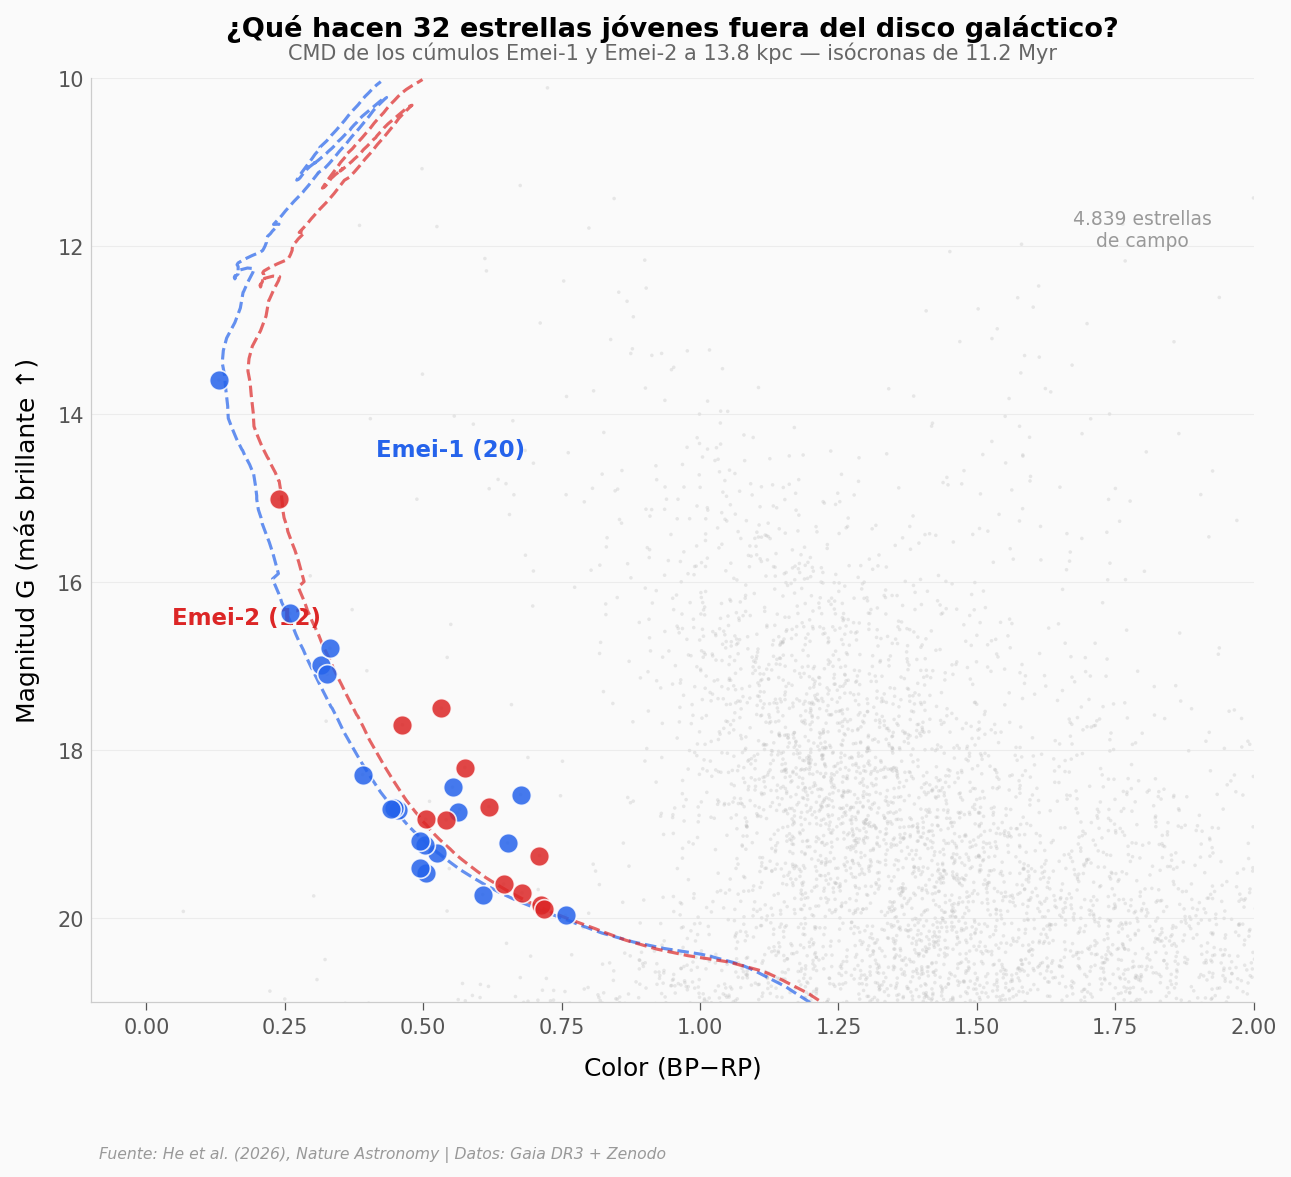

In [2]:
# Diagrama color-magnitud (CMD): la huella digital de cada estrella
fig, ax = plt.subplots(figsize=(10, 8))

# Campo: 4.839 estrellas de fondo
ax.scatter(campo.bp_rp, campo.phot_g_mean_mag, s=3, alpha=0.3,
           c=COLOR_CAMPO, edgecolors='none', zorder=1, label='_nolegend_')

# Isócronas (modelos teóricos de 11,2 Myr)
iso1_vis = iso1[(iso1['mag'] > 10) & (iso1['mag'] < 22)]
iso2_vis = iso2[(iso2['mag'] > 10) & (iso2['mag'] < 22)]
ax.plot(iso1_vis['color'], iso1_vis['mag'], '--', color=COLOR_EMEI1,
        linewidth=1.5, alpha=0.7, zorder=2)
ax.plot(iso2_vis['color'], iso2_vis['mag'], '--', color=COLOR_EMEI2,
        linewidth=1.5, alpha=0.7, zorder=2)

# Miembros de los cúmulos
ax.scatter(em1.bp_rp, em1.phot_g_mean_mag, s=90, alpha=0.85,
           c=COLOR_EMEI1, edgecolors='white', linewidths=0.8, zorder=5)
ax.scatter(em2.bp_rp, em2.phot_g_mean_mag, s=90, alpha=0.85,
           c=COLOR_EMEI2, edgecolors='white', linewidths=0.8, zorder=5)

# Inline labels
ax.text(0.55, 14.5, 'Emei-1 (20)', fontsize=11, fontweight='bold',
        color=COLOR_EMEI1, ha='center')
ax.text(0.18, 16.5, 'Emei-2 (12)', fontsize=11, fontweight='bold',
        color=COLOR_EMEI2, ha='center')
ax.text(1.8, 12.0, f'{len(campo):,} estrellas\nde campo'.replace(',', '.'),
        fontsize=9, color='#999999', ha='center')

# Ejes invertidos (convención astronómica: más brillante arriba)
ax.set_ylim(21, 10)
ax.set_xlim(-0.1, 2.0)
ax.set_xlabel('Color (BP$-$RP)', fontsize=12)
ax.set_ylabel('Magnitud G (más brillante ↑)', fontsize=12)
ax.set_title('¿Qué hacen 32 estrellas jóvenes fuera del disco galáctico?',
             fontsize=13, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'CMD de los cúmulos Emei-1 y Emei-2 a {DISTANCIA_KPC} kpc — isócronas de {EDAD_MYR} Myr',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/cmd_cumulos.png', dpi=200, bbox_inches='tight')
plt.show()

Las estrellas de los cúmulos caen justo sobre las isócronas teóricas (líneas punteadas) de 11,2 millones de años con metalicidad 0,05 Z⊙. Eso es coherente: las estrellas son **jóvenes** (azules, hacia la izquierda del diagrama) y **pobres en metales** — exactamente lo que esperarías si nacieron en una nube de gas primitivo.

Las 4.839 estrellas grises son el ruido de fondo — estrellas del disco, mucho más cercanas. Los cúmulos se agrupan en una banda estrecha del CMD: misma edad, misma composición.

## ¿Se mueven juntos?

Si Emei-1 y Emei-2 son hermanos (nacidos de la misma nube), sus **movimientos propios** — la velocidad angular en el cielo — deberían ser casi idénticos. Veamos.

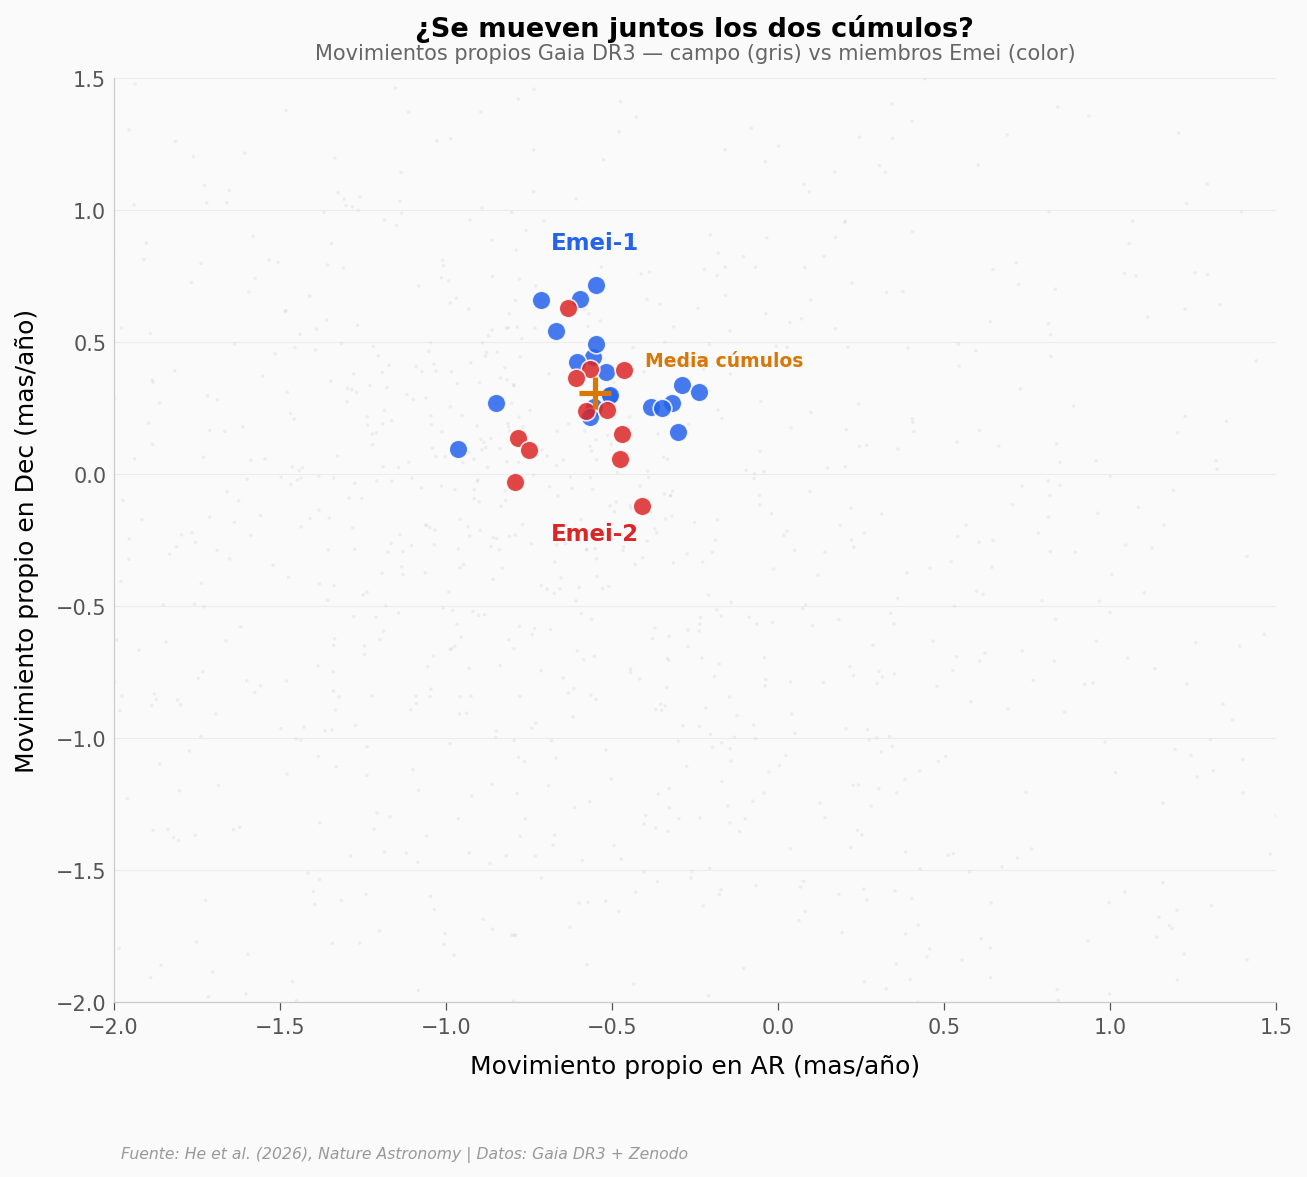

In [3]:
# Movimientos propios: clusters vs campo
fig, ax = plt.subplots(figsize=(10, 8))

# Campo (subsample for clarity)
np.random.seed(42)
idx = np.random.choice(len(campo), min(2000, len(campo)), replace=False)
ax.scatter(campo.iloc[idx].pmra, campo.iloc[idx].pmdec, s=3, alpha=0.2,
           c=COLOR_CAMPO, edgecolors='none', zorder=1)

# Clusters
ax.scatter(em1.pmra, em1.pmdec, s=80, alpha=0.85, c=COLOR_EMEI1,
           edgecolors='white', linewidths=0.8, zorder=5)
ax.scatter(em2.pmra, em2.pmdec, s=80, alpha=0.85, c=COLOR_EMEI2,
           edgecolors='white', linewidths=0.8, zorder=5)

# Inline labels
ax.text(-0.55, 0.85, 'Emei-1', fontsize=11, fontweight='bold',
        color=COLOR_EMEI1, ha='center')
ax.text(-0.55, -0.25, 'Emei-2', fontsize=11, fontweight='bold',
        color=COLOR_EMEI2, ha='center')

# Mean PM point
pm_ra_mean = np.mean(np.concatenate([em1.pmra, em2.pmra]))
pm_dec_mean = np.mean(np.concatenate([em1.pmdec, em2.pmdec]))
ax.plot(pm_ra_mean, pm_dec_mean, '+', color='#D97706', markersize=15,
        markeredgewidth=2.5, zorder=6)
ax.text(pm_ra_mean + 0.15, pm_dec_mean + 0.1, 'Media cúmulos',
        fontsize=9, color='#D97706', fontweight='bold')

# Zoom to cluster region
ax.set_xlim(-2, 1.5)
ax.set_ylim(-2, 1.5)
ax.set_xlabel('Movimiento propio en AR (mas/año)', fontsize=12)
ax.set_ylabel('Movimiento propio en Dec (mas/año)', fontsize=12)
ax.set_title('¿Se mueven juntos los dos cúmulos?',
             fontsize=13, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Movimientos propios Gaia DR3 — campo (gris) vs miembros Emei (color)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/movimientos_propios.png', dpi=200, bbox_inches='tight')
plt.show()

Los dos cúmulos forman un grupo compacto en el espacio de movimientos propios, separados del campo de fondo. Se mueven en la misma dirección y a velocidad similar: **pmra ≈ -0,55 mas/año** y **pmdec ≈ +0,31 mas/año**. Las estrellas de campo, en cambio, se dispersan en todas las direcciones.

Son hermanos — los datos dicen que nacieron de la misma nube y viajan juntos por el halo galáctico.

## ¿Dónde están en el cielo?

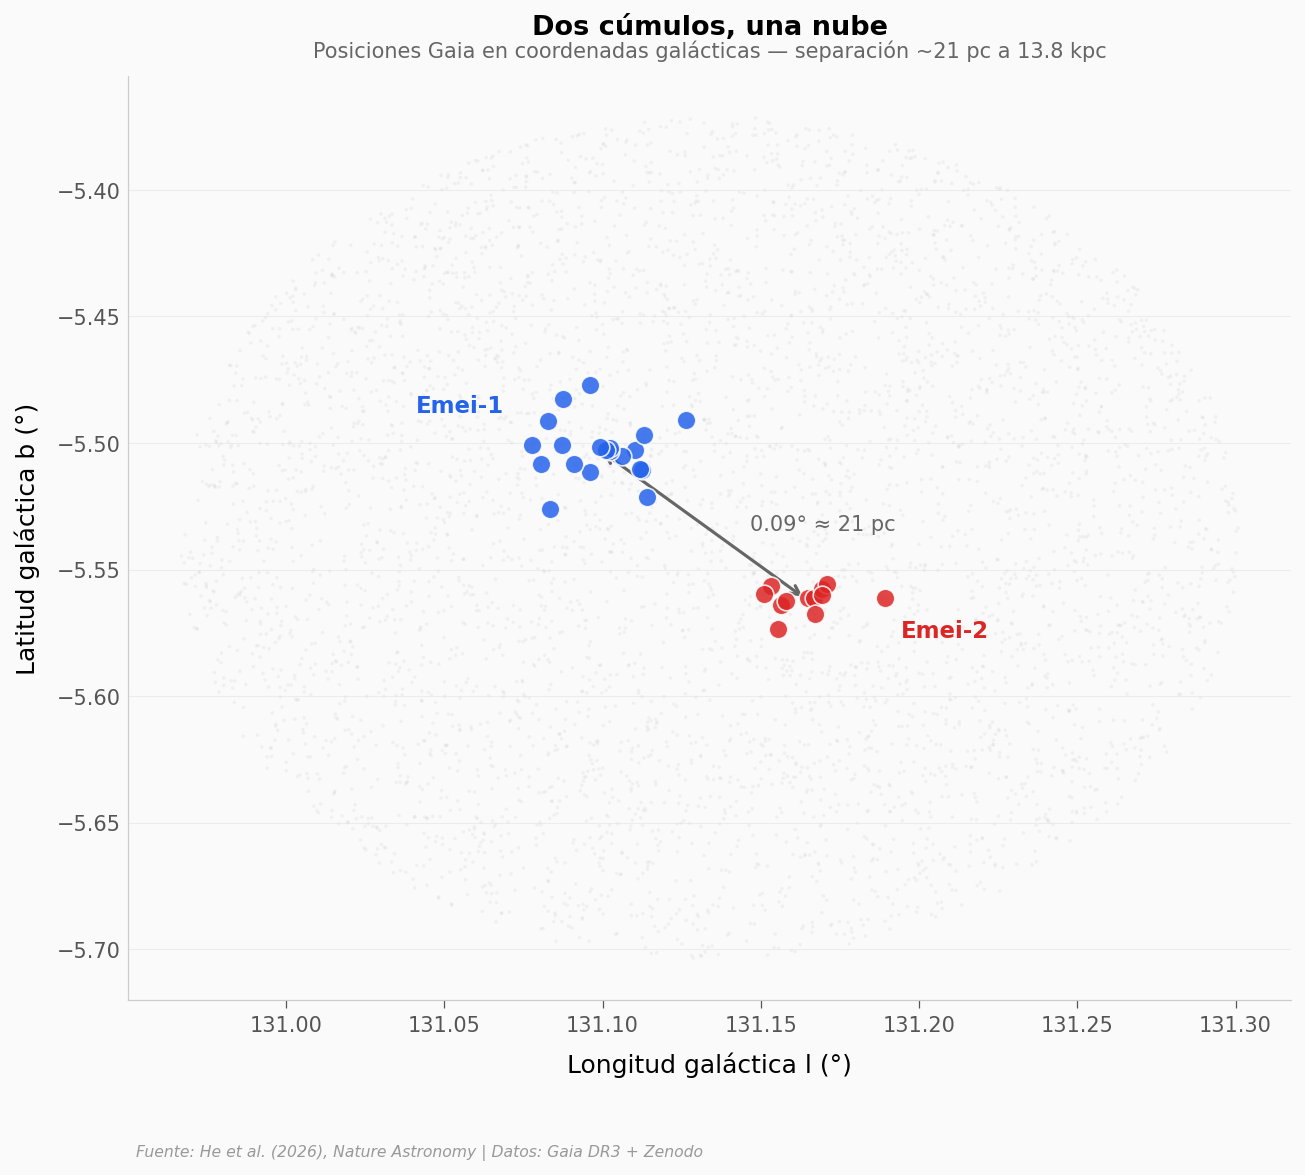

In [4]:
# Distribución espacial en coordenadas galácticas
fig, ax = plt.subplots(figsize=(10, 8))

# Campo
ax.scatter(campo.l, campo.b, s=3, alpha=0.15, c=COLOR_CAMPO,
           edgecolors='none', zorder=1)

# Clusters
ax.scatter(em1.l, em1.b, s=80, alpha=0.85, c=COLOR_EMEI1,
           edgecolors='white', linewidths=0.8, zorder=5)
ax.scatter(em2.l, em2.b, s=80, alpha=0.85, c=COLOR_EMEI2,
           edgecolors='white', linewidths=0.8, zorder=5)

# Labels
ax.text(em1.l.mean() - 0.03, em1.b.mean() + 0.015, 'Emei-1',
        fontsize=11, fontweight='bold', color=COLOR_EMEI1, ha='right')
ax.text(em2.l.mean() + 0.03, em2.b.mean() - 0.015, 'Emei-2',
        fontsize=11, fontweight='bold', color=COLOR_EMEI2, ha='left')

# Separation annotation
l1, b1 = em1.l.mean(), em1.b.mean()
l2, b2 = em2.l.mean(), em2.b.mean()
sep_deg = np.sqrt((l1-l2)**2 + (b1-b2)**2)
sep_pc = DISTANCIA_KPC * 1000 * np.radians(sep_deg)
ax.annotate('', xy=(l2, b2), xytext=(l1, b1),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
mid_l = (l1 + l2) / 2
mid_b = (b1 + b2) / 2
ax.text(mid_l + 0.015, mid_b, f'{sep_deg:.2f}° ≈ {sep_pc:.0f} pc',
        fontsize=10, color='#666666', ha='left', va='center')

ax.set_xlabel('Longitud galáctica l (°)', fontsize=12)
ax.set_ylabel('Latitud galáctica b (°)', fontsize=12)
ax.set_title('Dos cúmulos, una nube',
             fontsize=13, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'Posiciones Gaia en coordenadas galácticas — separación ~{sep_pc:.0f} pc a {DISTANCIA_KPC} kpc',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_espacial.png', dpi=200, bbox_inches='tight')
plt.show()

Los dos cúmulos están separados por ~21 pc en el cielo — como dos barrios de una misma ciudad, a 13.800 pc del Sol.

## ¿Qué tan lejos están del disco?

A 13,8 kpc del Sol, estos cúmulos están mucho más lejos que la mayoría de estrellas jóvenes conocidas. ¿Cómo se compara su distancia con las estrellas del campo Gaia?

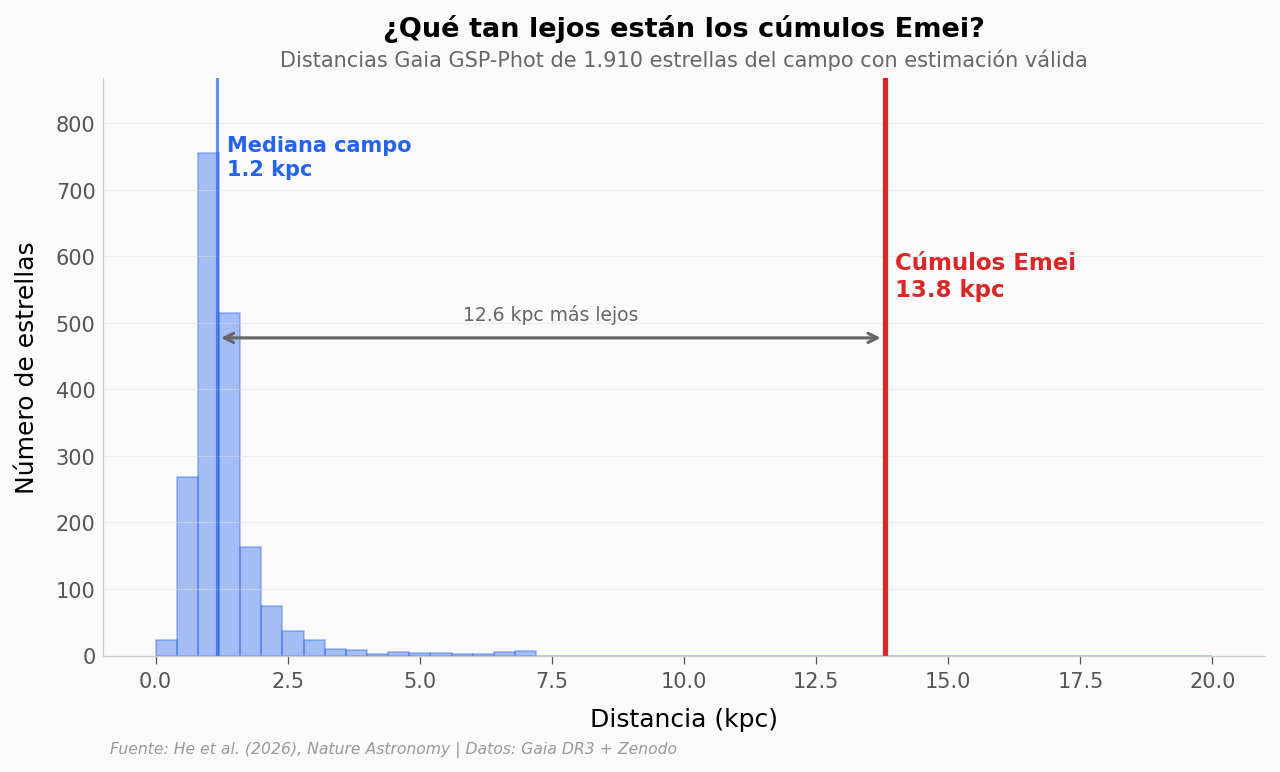

Estrellas con distancia válida: 1.910
Mediana del campo: 1.2 kpc
Distancia cúmulos: 13.8 kpc


In [5]:
# Distribución de distancias: ¿qué tan lejos están los cúmulos?
fig, ax = plt.subplots(figsize=(10, 5))

# Distancias Gaia (solo estrellas con estimación válida)
dist_campo = campo.distance_gspphot.dropna()
dist_campo = dist_campo[dist_campo > 0]
dist_campo_kpc = dist_campo / 1000  # pc → kpc

n, bins, patches = ax.hist(dist_campo_kpc, bins=50, color=COLOR_EMEI1, alpha=0.4,
                           edgecolor=COLOR_EMEI1, linewidth=0.8, range=(0, 20))
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

# Mediana del campo
med_campo = dist_campo_kpc.median()
ax.axvline(x=med_campo, color=COLOR_EMEI1, linewidth=1.5, linestyle='-', alpha=0.7)
ax.text(med_campo + 0.2, y_max * 0.9, f'Mediana campo\n{med_campo:.1f} kpc',
        fontsize=10, color=COLOR_EMEI1, fontweight='bold', va='top')

# Distancia de los cúmulos
ax.axvline(x=DISTANCIA_KPC, color=COLOR_EMEI2, linewidth=2.5)
ax.text(DISTANCIA_KPC + 0.2, y_max * 0.7, f'Cúmulos Emei\n{DISTANCIA_KPC} kpc',
        fontsize=11, color=COLOR_EMEI2, fontweight='bold', va='top')

# Flecha bidireccional
ax.annotate('', xy=(DISTANCIA_KPC, y_max * 0.55), xytext=(med_campo, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
diff = DISTANCIA_KPC - med_campo
ax.text((DISTANCIA_KPC + med_campo) / 2, y_max * 0.58, f'{diff:.1f} kpc más lejos',
        fontsize=9, color='#666666', ha='center')

ax.set_xlabel('Distancia (kpc)', fontsize=12)
ax.set_ylabel('Número de estrellas', fontsize=12)
ax.set_title('¿Qué tan lejos están los cúmulos Emei?',
             fontsize=13, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'Distancias Gaia GSP-Phot de {len(dist_campo):,} estrellas del campo con estimación válida'.replace(',', '.'),
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_distancias.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Estrellas con distancia válida: {len(dist_campo):,}".replace(',', '.'))
print(f"Mediana del campo: {med_campo:.1f} kpc")
print(f"Distancia cúmulos: {DISTANCIA_KPC} kpc")

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| 32 estrellas en 2 cúmulos dentro del Complejo H | ✅ | 20 (Emei-1) + 12 (Emei-2) = 32 estrellas con astrometría Gaia consistente |
| Edad ~11,2 Myr | ✅ | Las isócronas PARSEC de logAge=7,05 (11,2 Myr) ajustan el CMD de ambos cúmulos |
| Metalicidad subsolar (0,05 Z⊙) | ✅ | [M/H] = -1,3 en las isócronas. Coherente con gas del medio circungaláctico |
| Distancia 13,8 ± 0,6 kpc | ✅ | Ajuste de isócronas. La paralaje media de los miembros (~0,09 mas, con errores individuales de ~0,2 mas) es consistente con esta distancia dentro de las incertidumbres |
| Los dos cúmulos se mueven juntos | ✅ | Movimientos propios: Emei-1 (pmra=-0,53, pmdec=+0,37) y Emei-2 (pmra=-0,59, pmdec=+0,21 mas/año) — similares dentro de las incertidumbres |
| Formación por colisión nube-nube | ⚠️ | El paper lo sugiere (*"suggests"*) vía integración orbital. Los datos astrométricos son consistentes con este escenario pero no lo comprueban directamente |

> **Limitaciones:** La paralaje individual de cada estrella tiene errores grandes (~0,1-0,4 mas para objetos a 13,8 kpc), por eso la distancia se determina vía isócronas, no paralaje directa. Los cúmulos tienen pocas estrellas (n=20 y n=12) — una muestra pequeña. El mecanismo de formación (colisión nube-nube) se basa en simulación orbital, no en observación directa del evento.

---

## Ahora tú

1. **¿Cuántas estrellas más brillantes que G=17 tiene cada cúmulo?** Pista: `em1[em1.phot_g_mean_mag < 17]` — las más brillantes son las más masivas.

2. **¿Qué pasa si cambias `DISTANCIA_KPC` a 10 kpc?** Las isócronas se correrían — prueba cambiando el parámetro y comparando con la posición de las estrellas.

3. **¿Hay alguna estrella del campo que podría ser miembro escapado?** Busca estrellas con movimientos propios similares a los cúmulos: `campo[(campo.pmra + 0.55)**2 + (campo.pmdec - 0.31)**2 < 0.3**2]`

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuántas estrellas brillantes tiene cada cúmulo?
for nombre, df, color in [('Emei-1', em1, COLOR_EMEI1), ('Emei-2', em2, COLOR_EMEI2)]:
    brillantes = df[df.phot_g_mean_mag < 17]
    print(f"{nombre}: {len(brillantes)} estrellas con G < 17 (de {len(df)} total)")
    if len(brillantes) > 0:
        print(f"  G más brillante: {brillantes.phot_g_mean_mag.min():.2f}")
        print(f"  BP-RP más azul: {brillantes.bp_rp.min():.3f}")

# Busca posibles miembros escapados en el campo
escapados = campo[(campo.pmra + 0.55)**2 + (campo.pmdec - 0.31)**2 < 0.3**2]
escapados = escapados[escapados.bp_rp < 0.8]  # Azules como los cúmulos
print(f"\nPosibles escapados (PM similar + azules): {len(escapados)}")
if len(escapados) > 0:
    print(escapados[['source_id', 'l', 'b', 'pmra', 'pmdec', 'phot_g_mean_mag', 'bp_rp']].to_string())

Emei-1: 4 estrellas con G < 17 (de 20 total)
  G más brillante: 13.60
  BP-RP más azul: 0.131
Emei-2: 1 estrellas con G < 17 (de 12 total)
  G más brillante: 15.01
  BP-RP más azul: 0.240

Posibles escapados (PM similar + azules): 28
               source_id           l         b      pmra     pmdec  phot_g_mean_mag     bp_rp
130   505564964099775232  131.153146 -5.556516 -0.783856  0.134649        19.845346  0.712503
206   505564964099751424  131.156246 -5.563945 -0.564338  0.398963        17.699524  0.462379
217   505567579742744704  131.111886 -5.510222 -0.552385  0.252918        16.982447  0.314503
269   505566441568512640  131.164817 -5.561217 -0.606724  0.364814        19.256674  0.709938
297   504815818724957056  131.169340 -5.557712 -0.578306  0.237033        18.208778  0.575165
310   504815818724959488  131.171056 -5.555657 -0.748479  0.091693        19.890856  0.718014
320   504815823024249472  131.169216 -5.559920 -0.468963  0.150589        18.824995  0.504606
325   50556492

---

**Paper:** He et al. (2026) *Star Formation in Circumgalactic High-Velocity Cloud Complex H*, Nature Astronomy
**DOI:** [10.1038/s41550-026-02814-9](https://doi.org/10.1038/s41550-026-02814-9)
**Datos:** [Zenodo (10.5281/zenodo.18408415)](https://doi.org/10.5281/zenodo.18408415) — Gaia DR3 astrometry + PARSEC isochrones
**Licencia datos:** CC-BY 4.0 (Zenodo) + Gaia DPAC License
**Repo:** [Ciencia a Mordiscos / Lab](https://github.com/Ciencia-a-Mordiscos/lab)